C:\Users\gayat\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\gayat\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


✓ Model saved as 'lasso_model.joblib' and predictions saved to 'predictions_lasso.csv'
Accuracy: 0.9333 | ROC-AUC: 0.9911 | F1: 0.8667


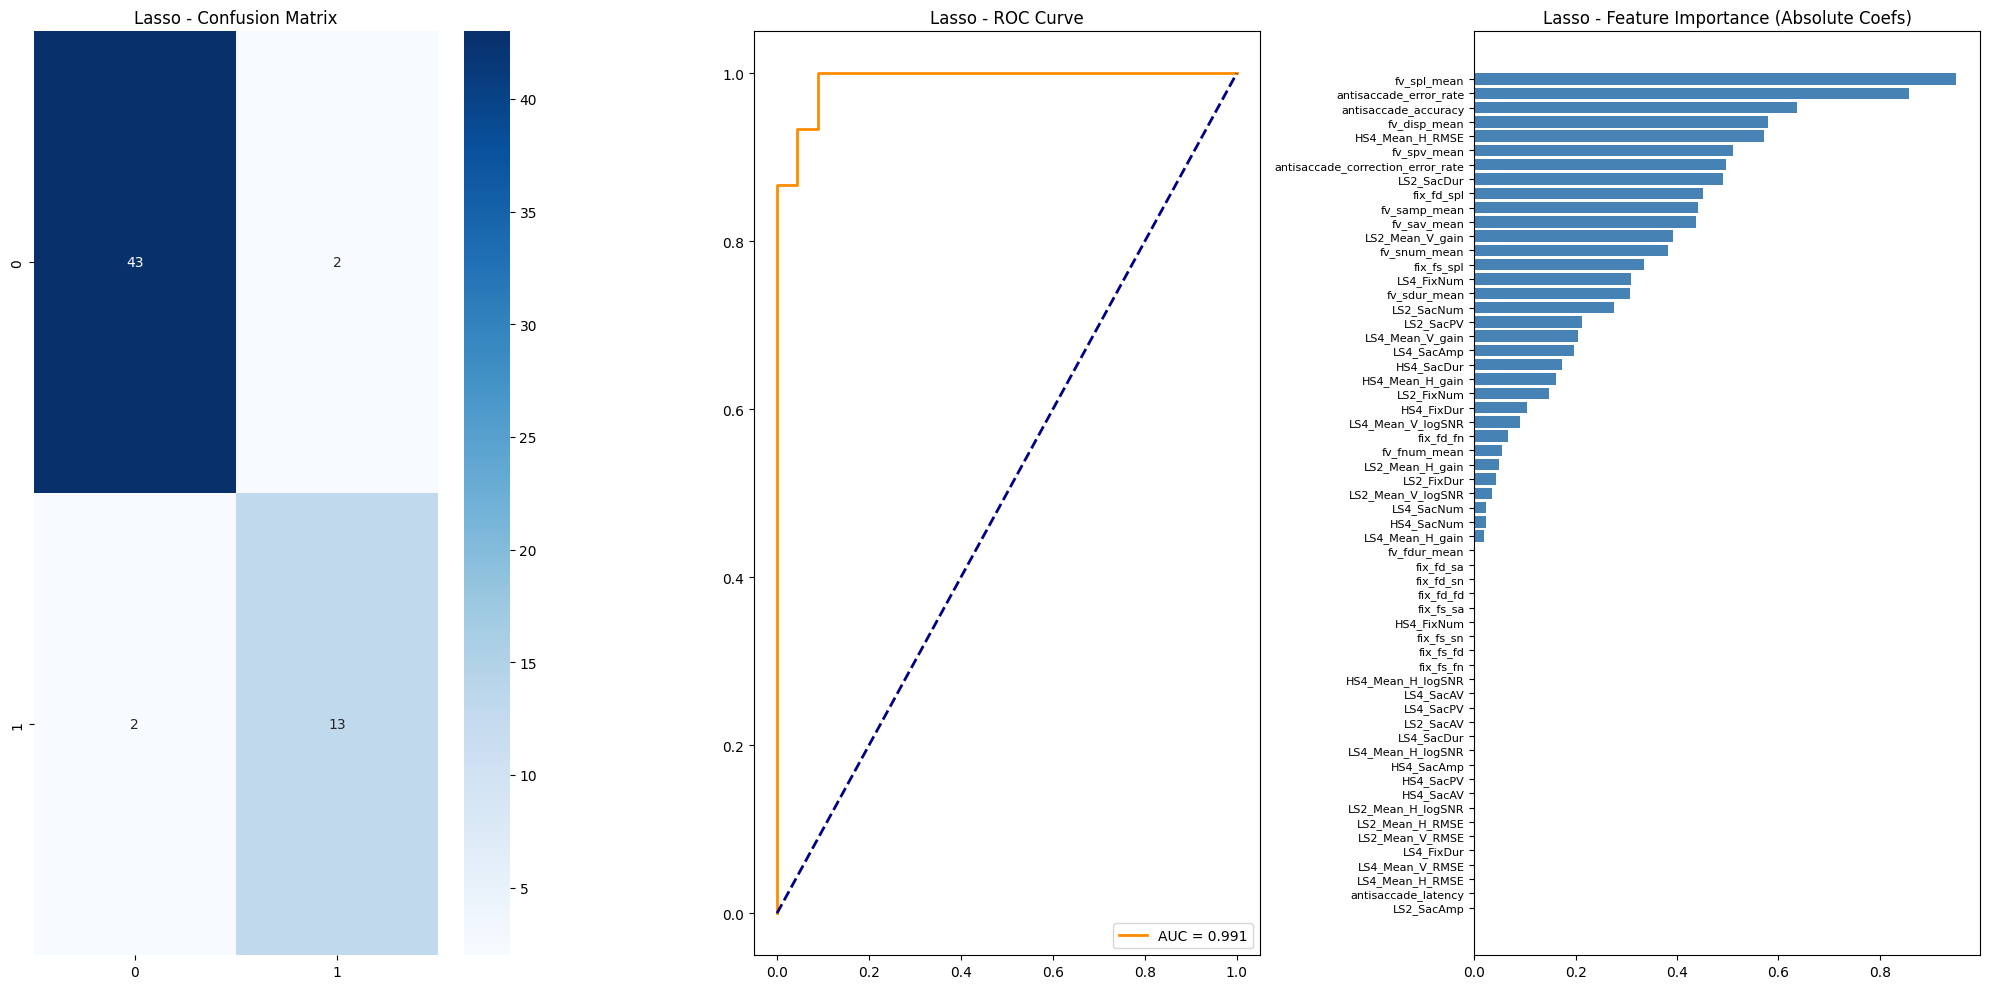

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression

# 1. Load Data
df = pd.read_csv('synthetic_eye_tracking_HC_SZ_300.csv')

# Isolate features not for training
X = df.drop(columns=['subject_id', 'label', 'calibration_error'])
y_raw = df['label']
sub_ids = df['subject_id']
cal_errors = df['calibration_error']

# Encode Labels (e.g., 'HC' -> 0)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test, sub_train, sub_test, cal_train, cal_test = train_test_split(
    X, y, sub_ids, cal_errors, test_size=0.2, stratify=y, random_state=42
)

# 3. Scale Features (Required for Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
feature_names = X.columns.tolist()

# 4. Train Model
model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 6. Save Model & Predictions
joblib.dump(model, 'lasso_model.joblib')

results_df = pd.DataFrame({
    'subject_id': sub_test.values,
    'actual_label': y_test,
    'predicted_label': y_pred,
    'predicted_prob': y_prob,
    'calibration_error': cal_test.values
})
results_df.to_csv('predictions_lasso.csv', index=False)
print("✓ Model saved as 'lasso_model.joblib' and predictions saved to 'predictions_lasso.csv'")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f} | F1: {f1_score(y_test, y_pred):.4f}")

# 7. Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Lasso - Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("Lasso - ROC Curve")
axes[1].legend(loc="lower right")

# Feature Importance (Absolute Coefficients)
importances = np.abs(model.coef_[0])
indices = np.argsort(importances)
axes[2].barh(range(len(indices)), importances[indices], color='steelblue')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([feature_names[i] for i in indices], fontsize=8)
axes[2].set_title("Lasso - Feature Importance (Absolute Coefs)")

plt.tight_layout()
plt.show()